# 242: Does combining alphabets lift the partner to the top?

Notebook 241 searched Ced9, P66 and BHF against the 19_732 canonical human proteins with
all 19 kmerseek alphabets (152 arms, an arm being one alphabet at one seed length k). No
single arm put the known partner near the top: BCL2's best rank was 213 (polarity4, mean
IDF, k=9), CD47's 166 (hp_lehninger_hpc3, E-value, k=14).

The idea tested here: each alphabet merges different residues, so the chance hits at the
top of one alphabet's list should be different proteins from those at the top of another,
while a true match stays high in many. Combining the ranks across alphabets could then
sort the partner above the chance hits even though no single E-value can.

Two limits hold whatever the result. The alphabets are not independent views: they are
all functions of the same two sequences, and their classes nest. And a combined rank can
improve the rank, not the E-value: no reduced alphabet carries more than the 20-letter
matrix, about 0.38 bits per position, so the 37-residue BH1 block tops out near 14 bits
against the ~32 an E-value of 1 costs on this proteome (Part 2 of the kmerseek docs).

**The combined rank.** For one query and one metric, each arm ranks the proteins it hit by
their best region. A protein's normalised rank at an arm is its rank over 19_732; a protein
the arm did not hit gets the middle of the tied bottom ranks. The combined score is the
geometric mean of the normalised ranks (a rank product). Arms of one alphabet are averaged
first, so each alphabet counts once however many k it was run at. Code:
`alphabet_ensemble_utils.py`. No new search is run for sections 1 to 4.

In [1]:
import sys
from pathlib import Path

import numpy as np
import polars as pl
from scipy.stats import spearmanr

sys.path.insert(0, str(Path.cwd()))
import alphabet_ensemble_utils as ae

pl.Config.set_tbl_rows(60)
pl.Config.set_tbl_width_chars(240)
pl.Config.set_tbl_cols(20)
FIG = ae.FIG

scores, summaries = {}, []
for m in ae.METRICS:
    s, arms = ae.ensemble(m)
    scores[m] = s
    summaries.append(ae.partner_summary(s, arms, m))
summary = pl.concat(summaries)
print(f"{len(ae.METRICS)} metrics x 3 queries; each protein scored over the arms where its query has any hit")

5 metrics x 3 queries; each protein scored over the arms where its query has any hit


## 1. The combined rank puts both partners lower, not higher

Open circle: the partner's best rank at any single arm. Filled square: its rank once all
19 alphabets are combined. The grey rows are a control: CD47 when Ced9 is the query, a
pair with no known link.

/Users/olga/code/2024-kmerseek-analysis/.claude/worktrees/alphabet-ensemble/notebooks/hp_conservation_utils.py:277: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


shape: (15, 10)
┌───────┬─────────┬─────────────────┬──────────────────┬───────────────────────────────┬──────────────────────┬─────────────────┬────────────────┬─────────────────┬─────────────────────────────┐
│ query ┆ partner ┆ metric          ┆ best_single_rank ┆ best_single_arm               ┆ ens_rank_by_alphabet ┆ ens_rank_by_arm ┆ votes_alphabet ┆ n_alphabets_hit ┆ pct_by_alphabet_among_peers │
│ ---   ┆ ---     ┆ ---             ┆ ---              ┆ ---                           ┆ ---                  ┆ ---             ┆ ---            ┆ ---             ┆ ---                         │
│ str   ┆ str     ┆ str             ┆ i64              ┆ str                           ┆ i64                  ┆ i64             ┆ i64            ┆ i64             ┆ f64                         │
╞═══════╪═════════╪═════════════════╪══════════════════╪═══════════════════════════════╪══════════════════════╪═════════════════╪════════════════╪═════════════════╪═════════════════════════════╡
│ Ced9  ┆

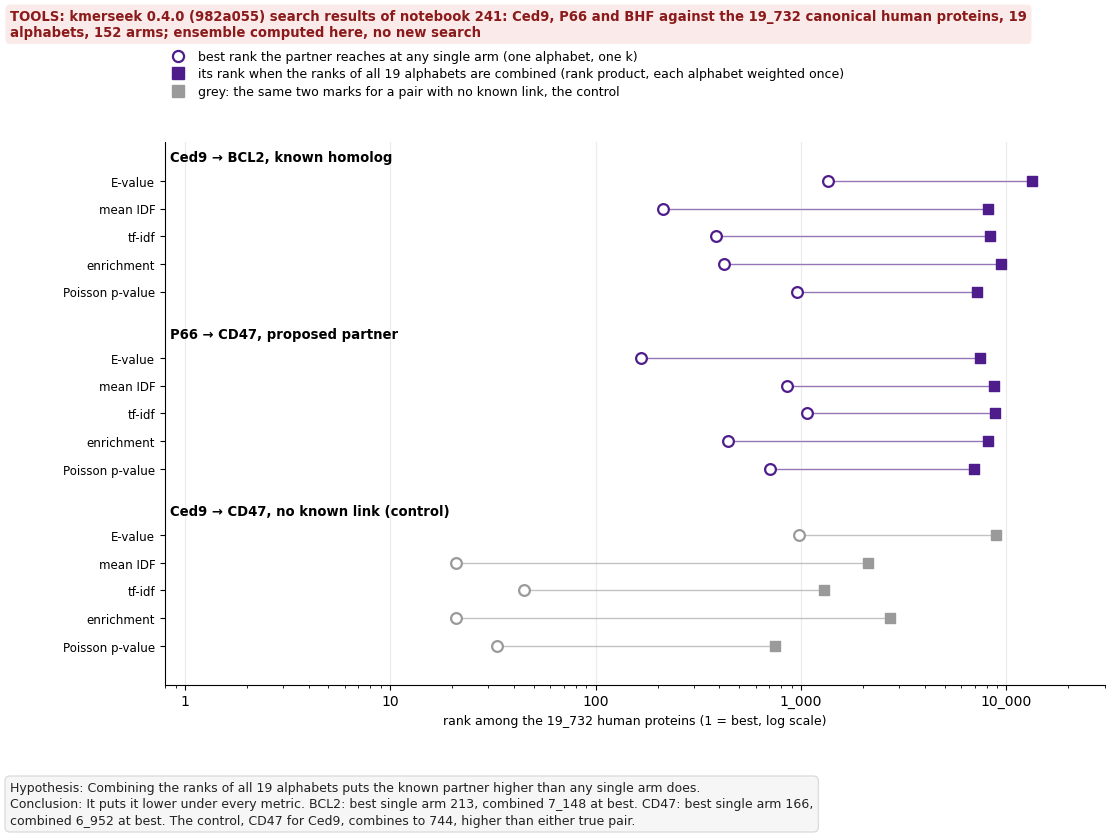

In [2]:
pairs = summary.filter(
    ((pl.col("query") == "Ced9") & (pl.col("partner") == "BCL2"))
    | ((pl.col("query") == "P66") & (pl.col("partner") == "CD47"))
    | ((pl.col("query") == "Ced9") & (pl.col("partner") == "CD47")))
true = pairs.filter(pl.col("is_true_pair"))
ae.fig_single_vs_ensemble(
    pairs, FIG / "242_single_arm_vs_combined_rank.png",
    hypothesis="Combining the ranks of all 19 alphabets puts the known partner higher than any single arm does.",
    conclusion=(
        f"It puts it lower under every metric. BCL2: best single arm {true.filter(pl.col('partner') == 'BCL2')['best_single_rank'].min()}, "
        f"combined {true.filter(pl.col('partner') == 'BCL2')['ens_rank_by_alphabet'].min():_} at best. "
        f"CD47: best single arm {true.filter(pl.col('partner') == 'CD47')['best_single_rank'].min()}, combined "
        f"{true.filter(pl.col('partner') == 'CD47')['ens_rank_by_alphabet'].min():_} at best. The control, CD47 for Ced9, "
        f"combines to {pairs.filter(~pl.col('is_true_pair'))['ens_rank_by_alphabet'].min():_}, higher than either true pair."),
)
print(pairs.select("query", "partner", "metric", "best_single_rank", "best_single_arm", "ens_rank_by_alphabet",
                   "ens_rank_by_arm", "votes_alphabet", "n_alphabets_hit", "pct_by_alphabet_among_peers")
      .sort("query", "partner", "metric", descending=[False, False, False]))

## 2. The same proteins beat the partner in most alphabets

The combination can only help if different proteins beat the partner in different
alphabets. For each alphabet that sees the partner, take the k where the partner ranks
best and list the proteins ranked above it there. Bars count the proteins that beat the
partner in exactly j of those alphabets; the line is the count expected if every alphabet
picked its list independently of the others. Picking each alphabet's best k for the
partner favours the partner, so the overlap measured here is a lower bound.

shape: (10, 8)
┌───────┬─────────┬─────────────────┬───────────┬──────────────────────┬─────────────────────────┬────────────────────────┬────────────────┐
│ query ┆ partner ┆ metric          ┆ alphabets ┆ beat_in_half_or_more ┆ expected_if_independent ┆ beat_in_every_alphabet ┆ times_expected │
│ ---   ┆ ---     ┆ ---             ┆ ---       ┆ ---                  ┆ ---                     ┆ ---                    ┆ ---            │
│ str   ┆ str     ┆ str             ┆ i64       ┆ i64                  ┆ f64                     ┆ i64                    ┆ f64            │
╞═══════╪═════════╪═════════════════╪═══════════╪══════════════════════╪═════════════════════════╪════════════════════════╪════════════════╡
│ Ced9  ┆ BCL2    ┆ E-value         ┆ 3         ┆ 1412                 ┆ 1015.7                  ┆ 154                    ┆ 1.4            │
│ Ced9  ┆ BCL2    ┆ mean IDF        ┆ 13        ┆ 1200                 ┆ 152.5                   ┆ 0                      ┆ 7.9            

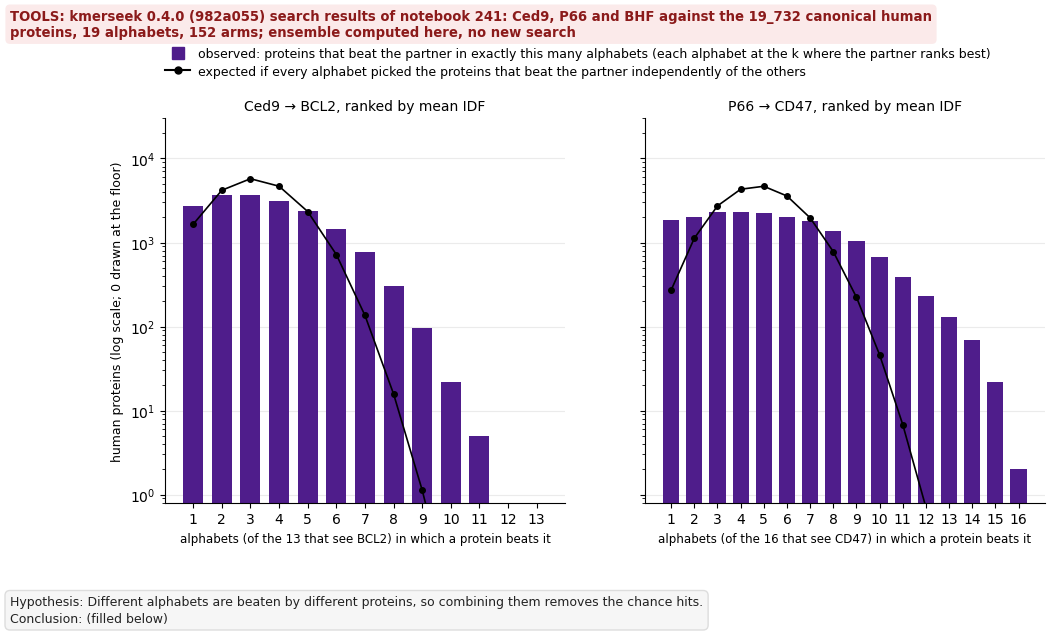

In [3]:
crowd = ae.fig_same_crowd(
    [("Ced9", "BCL2", "mean IDF"), ("P66", "CD47", "mean IDF")], FIG / "242_same_proteins_beat_the_partner.png",
    hypothesis="Different alphabets are beaten by different proteins, so combining them removes the chance hits.",
    conclusion="(filled below)",
)
rows = []
for q, p in [("Ced9", "BCL2"), ("P66", "CD47")]:
    for m in ae.METRICS:
        pa, pp = ae.beat_counts(m, q, p)
        A = pa.height
        exp = ae.independent_expectation(pa)
        half = (A + 1) // 2
        rows.append(dict(query=q, partner=p, metric=m, alphabets=A,
                         beat_in_half_or_more=pp.filter(pl.col("n_alphabets_beating") >= half).height,
                         expected_if_independent=round(float(exp[half:].sum()), 1),
                         beat_in_every_alphabet=pp.filter(pl.col("n_alphabets_beating") == A).height))
overlap = pl.DataFrame(rows).with_columns(
    (pl.col("beat_in_half_or_more") / pl.col("expected_if_independent")).round(1).alias("times_expected"))
print(overlap)

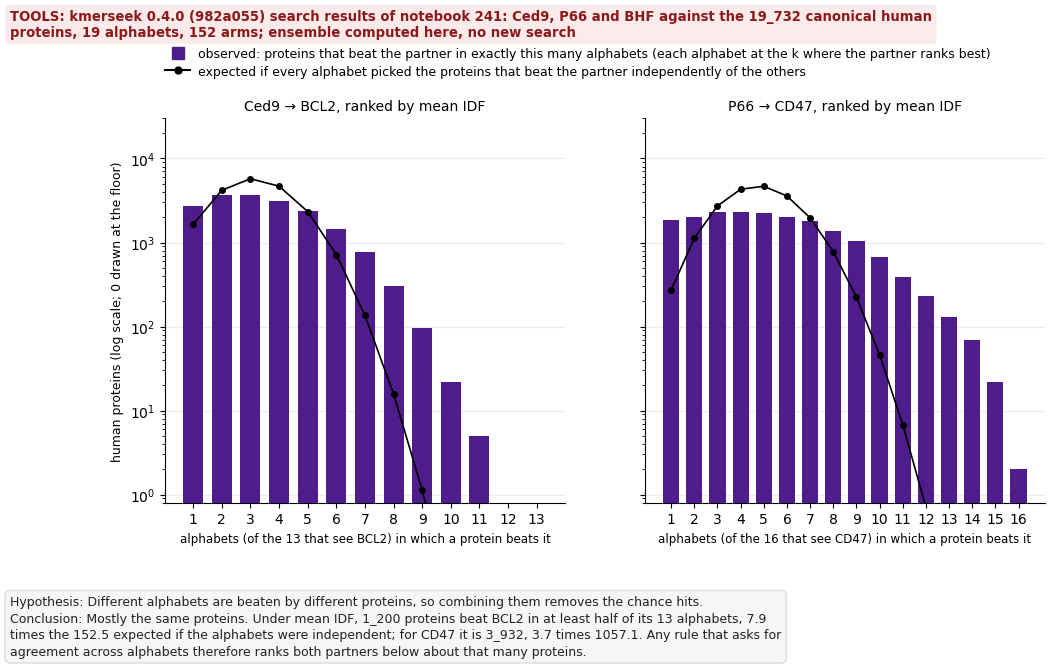

In [4]:
# Redraw with the conclusion computed from the table above.
b = overlap.filter((pl.col("partner") == "BCL2") & (pl.col("metric") == "mean IDF")).row(0, named=True)
c = overlap.filter((pl.col("partner") == "CD47") & (pl.col("metric") == "mean IDF")).row(0, named=True)
ae.fig_same_crowd(
    [("Ced9", "BCL2", "mean IDF"), ("P66", "CD47", "mean IDF")], FIG / "242_same_proteins_beat_the_partner.png",
    hypothesis="Different alphabets are beaten by different proteins, so combining them removes the chance hits.",
    conclusion=(f"Mostly the same proteins. Under mean IDF, {b['beat_in_half_or_more']:_} proteins beat BCL2 in at least half "
                f"of its {b['alphabets']} alphabets, {b['times_expected']} times the {b['expected_if_independent']} expected if the "
                f"alphabets were independent; for CD47 it is {c['beat_in_half_or_more']:_}, {c['times_expected']} times "
                f"{c['expected_if_independent']}. Any rule that asks for agreement across alphabets therefore ranks both "
                f"partners below about that many proteins."),
);

## 3. What the combined rank rewards instead: length

A protein hit at many arms keeps a good score at each of them, and the proteins hit at the
most arms are the longest ones. Below, every human protein's combined rank for BHF, the
query with no known partner, against its length.

shape: (8, 5)
┌────────┬────────┬──────────────────────┬────────────────┬─────────────────┐
│ gene   ┆ length ┆ ens_rank_by_alphabet ┆ votes_alphabet ┆ n_alphabets_hit │
│ ---    ┆ ---    ┆ ---                  ┆ ---            ┆ ---             │
│ str    ┆ i64    ┆ u32                  ┆ u32            ┆ u32             │
╞════════╪════════╪══════════════════════╪════════════════╪═════════════════╡
│ MUC16  ┆ 14507  ┆ 1                    ┆ 13             ┆ 19              │
│ ZC3H13 ┆ 1669   ┆ 2                    ┆ 16             ┆ 19              │
│ RSF1   ┆ 1441   ┆ 3                    ┆ 9              ┆ 18              │
│ ZNF608 ┆ 1512   ┆ 4                    ┆ 9              ┆ 19              │
│ SRRM2  ┆ 2752   ┆ 5                    ┆ 10             ┆ 17              │
│ FLG    ┆ 4061   ┆ 6                    ┆ 9              ┆ 15              │
│ TTN    ┆ 35991  ┆ 7                    ┆ 12             ┆ 19              │
│ PCLO   ┆ 5142   ┆ 8                    ┆ 10     

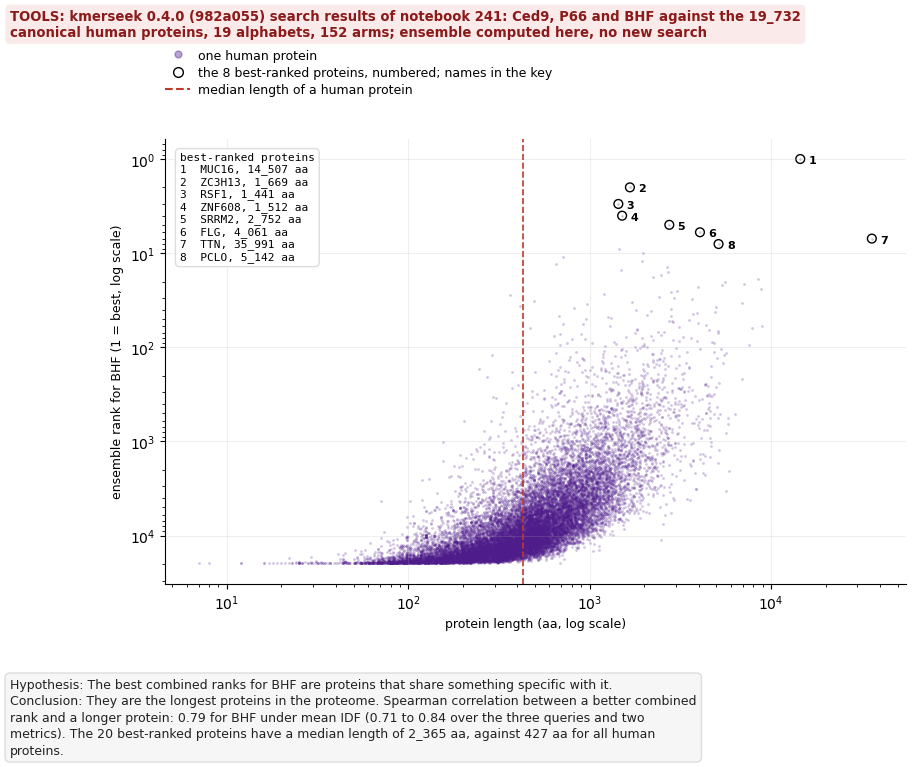

In [5]:
rho = {}
for m in ["mean IDF", "E-value"]:
    for q in ae.QUERIES:
        s = scores[m].filter(pl.col("query_name") == q)
        rho[(m, q)] = spearmanr(-s["log_rp_by_alphabet"], s["length"].cast(pl.Float64)).statistic
top = ae.fig_length_bias(
    scores["mean IDF"], "BHF", FIG / "242_combined_rank_rewards_length.png",
    hypothesis="The best combined ranks for BHF are proteins that share something specific with it.",
    conclusion=(lambda s: (
        f"They are the longest proteins in the proteome. Spearman correlation between a better combined rank and a "
        f"longer protein: {rho[('mean IDF', 'BHF')]:.2f} for BHF under mean IDF ({min(rho.values()):.2f} to "
        f"{max(rho.values()):.2f} over the three queries and two metrics). The 20 best-ranked proteins have a median length "
        f"of {int(s.sort('ens_rank_by_alphabet').head(20)['length'].median()):_} aa, against {int(s['length'].median())} aa "
        f"for all human proteins."))(scores["mean IDF"].filter(pl.col("query_name") == "BHF")),
)
print(top)
print(pl.DataFrame([dict(metric=m, query=q, spearman=round(v, 2)) for (m, q), v in rho.items()]))

## 4. CD47 ranks high for a query with no known link to it

In section 1, Ced9 ranks CD47 higher than P66 does, and higher than it ranks BCL2. A
protein that ranks high for unrelated queries is a sticky target, and a high rank for it
says little about any one query. The count below is measured on the two sequences: the
19-residue windows with at least 14 residues from AILMFVW, the length and make-up of a
membrane-spanning helix.

In [6]:
import re
seqs, name = {}, None
for line in open(ae.HUMAN_FASTA):
    if line.startswith(">"):
        g = line.split("|")[6]
        name = g if g in ("BCL2", "CD47") else None
        if name:
            seqs[name] = ""
    elif name:
        seqs[name] += line.strip()
rows = []
for g, s in seqs.items():
    n19 = sum(1 for i in range(len(s) - 18) if sum(c in "AILMFVW" for c in s[i:i + 19]) >= 14)
    rows.append(dict(protein=g, length_aa=len(s), windows_19_with_14_or_more_AILMFVW=n19))
print(pl.DataFrame(rows))
print()
print(summary.filter(pl.col("partner") == "CD47").select(
    "query", "metric", "best_single_rank", "best_single_arm", "ens_rank_by_alphabet", "pct_by_alphabet_among_peers").sort("query", "metric"))
print("\nFigure: section 1, grey rows.")

shape: (2, 3)
┌─────────┬───────────┬─────────────────────────────────┐
│ protein ┆ length_aa ┆ windows_19_with_14_or_more_AIL… │
│ ---     ┆ ---       ┆ ---                             │
│ str     ┆ i64       ┆ i64                             │
╞═════════╪═══════════╪═════════════════════════════════╡
│ CD47    ┆ 323       ┆ 33                              │
│ BCL2    ┆ 239       ┆ 0                               │
└─────────┴───────────┴─────────────────────────────────┘

shape: (15, 6)
┌───────┬─────────────────┬──────────────────┬───────────────────────────────┬──────────────────────┬─────────────────────────────┐
│ query ┆ metric          ┆ best_single_rank ┆ best_single_arm               ┆ ens_rank_by_alphabet ┆ pct_by_alphabet_among_peers │
│ ---   ┆ ---             ┆ ---              ┆ ---                           ┆ ---                  ┆ ---                         │
│ str   ┆ str             ┆ i64              ┆ str                           ┆ i64                  ┆ f64     

## 5. Only three alphabets: hp_lehninger2, polarity4, funcgroups8

These three are the alphabets in which PR #44 saw CD47 in view for P66. They were picked
after seeing where the partner appears, which tilts this test in the partner's favour.
Same combination as section 1, restricted to their arms.

/Users/olga/code/2024-kmerseek-analysis/.claude/worktrees/alphabet-ensemble/notebooks/hp_conservation_utils.py:277: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


shape: (20, 8)
┌───────┬─────────┬─────────────────┬──────────────────┬────────────────────┬──────────────────────┬───────┬─────────────────────────────┐
│ query ┆ partner ┆ metric          ┆ best_single_rank ┆ best_single_arm    ┆ ens_rank_by_alphabet ┆ all19 ┆ pct_by_alphabet_among_peers │
│ ---   ┆ ---     ┆ ---             ┆ ---              ┆ ---                ┆ ---                  ┆ ---   ┆ ---                         │
│ str   ┆ str     ┆ str             ┆ i64              ┆ str                ┆ i64                  ┆ i64   ┆ f64                         │
╞═══════╪═════════╪═════════════════╪══════════════════╪════════════════════╪══════════════════════╪═══════╪═════════════════════════════╡
│ Ced9  ┆ BCL2    ┆ E-value         ┆ 2042             ┆ hp_lehninger2 k=19 ┆ 6828                 ┆ 13343 ┆ 83.8                        │
│ Ced9  ┆ BCL2    ┆ Poisson p-value ┆ 2865             ┆ hp_lehninger2 k=19 ┆ 5307                 ┆ 7148  ┆ 87.1                        │
│ Ced9  ┆ BC

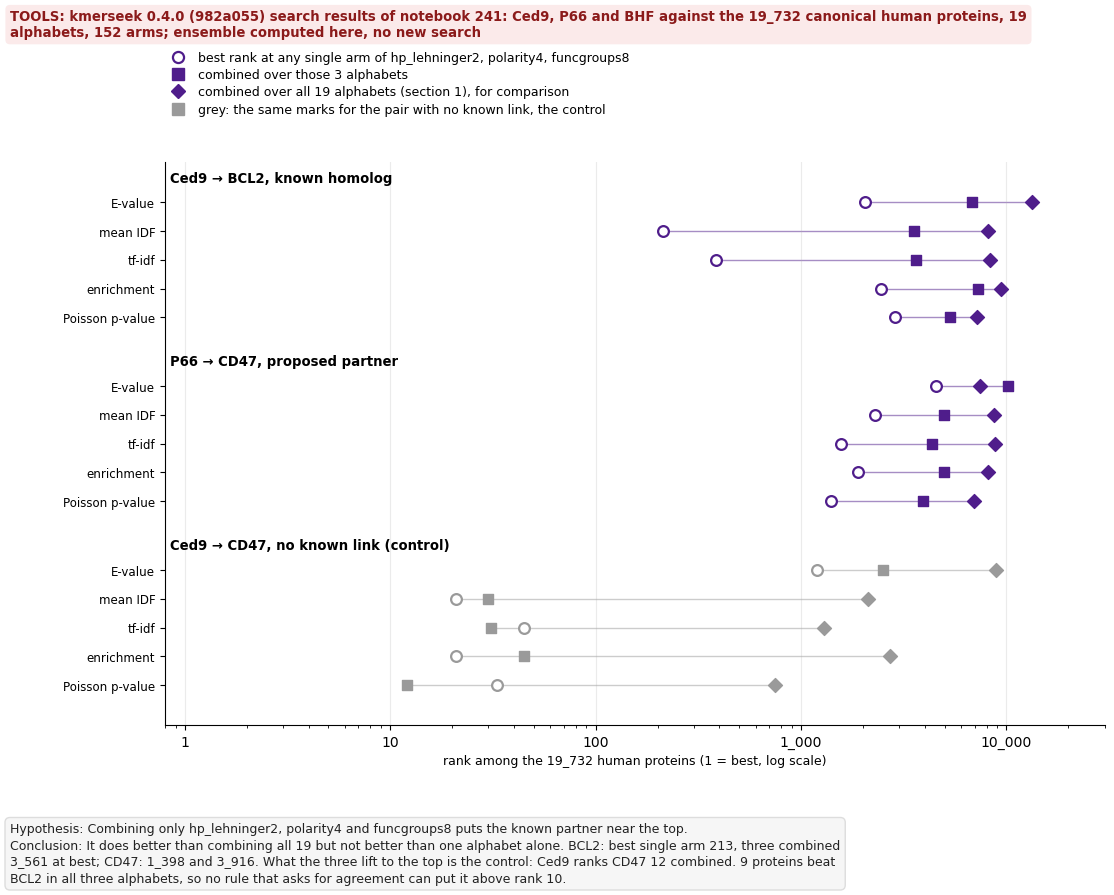

In [7]:
SUB = ae.SUBSET3
subrows = []
for m in ae.METRICS:
    s3, arms3 = ae.ensemble(m, SUB)
    subrows.append(ae.partner_summary(s3, arms3, m, alphabets=SUB)
                   .join(summary.filter(pl.col("metric") == m).select("query", "partner", pl.col("ens_rank_by_alphabet").alias("all19")),
                         on=["query", "partner"]))
    if m == "mean IDF":
        bhf3 = s3.filter(pl.col("query_name") == "BHF").sort("ens_rank_by_alphabet").head(8).select("gene", "length", "ens_rank_by_alphabet")
sub = pl.concat(subrows).filter(pl.col("query").is_in(["Ced9", "P66"]))
crowd3 = []
for q, p in [("Ced9", "BCL2"), ("P66", "CD47")]:
    pa, pp = ae.beat_counts("mean IDF", q, p, SUB)
    crowd3.append(dict(query=q, partner=p, beat_in_all_three=pp.filter(pl.col("n_alphabets_beating") == pa.height).height))
crowd3 = pl.DataFrame(crowd3)
t = sub.filter(pl.col("is_true_pair"))
ctl = sub.filter((pl.col("query") == "Ced9") & (pl.col("partner") == "CD47"))
ae.fig_subset(
    sub, FIG / "242_three_alphabets_only.png", SUB,
    hypothesis="Combining only hp_lehninger2, polarity4 and funcgroups8 puts the known partner near the top.",
    conclusion=(
        f"It does better than combining all 19 but not better than one alphabet alone. BCL2: best single arm "
        f"{t.filter(pl.col('partner') == 'BCL2')['best_single_rank'].min()}, three combined "
        f"{t.filter(pl.col('partner') == 'BCL2')['ens_rank_by_alphabet'].min():_} at best; CD47: "
        f"{t.filter(pl.col('partner') == 'CD47')['best_single_rank'].min():_} and "
        f"{t.filter(pl.col('partner') == 'CD47')['ens_rank_by_alphabet'].min():_}. What the three lift to the top is the control: "
        f"Ced9 ranks CD47 {ctl['ens_rank_by_alphabet'].min()} combined. "
        f"{crowd3.filter(pl.col('partner') == 'BCL2')['beat_in_all_three'][0]} proteins beat BCL2 in all three alphabets, "
        f"so no rule that asks for agreement can put it above rank "
        f"{crowd3.filter(pl.col('partner') == 'BCL2')['beat_in_all_three'][0] + 1}."),
)
print(sub.select("query", "partner", "metric", "best_single_rank", "best_single_arm", "ens_rank_by_alphabet", "all19",
                 "pct_by_alphabet_among_peers").sort("query", "partner", "metric"))
print(crowd3)
print("BHF, best 8 under the three combined (mean IDF):", bhf3.rows())

## 6. Every subset of 2, 3 and 4 alphabets, each at its best k, ranked by mean IDF

Each alphabet is used at one k: the k where Ced9 ranks BCL2 best under mean IDF (for the
six alphabets that never have BCL2 among the hits, their lowest-bit k). All 5_016 subsets
of 1 to 4 alphabets are combined as in section 1 and scored by mean IDF. Both the k and the
subset are picked by how well they rank BCL2, so the best subsets here are what an
optimist would report; the other two panels show whether the same subsets help CD47 and
the control, and section 7 gives every random query the same two picks.

/Users/olga/code/2024-kmerseek-analysis/.claude/worktrees/alphabet-ensemble/notebooks/hp_conservation_utils.py:277: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


shape: (4, 5)
┌──────┬─────────────────────────────────┬────────────┬───────────┬────────────┐
│ size ┆ subset                          ┆ Ced9->BCL2 ┆ P66->CD47 ┆ Ced9->CD47 │
│ ---  ┆ ---                             ┆ ---        ┆ ---       ┆ ---        │
│ i64  ┆ str                             ┆ i64        ┆ i64       ┆ i64        │
╞══════╪═════════════════════════════════╪════════════╪═══════════╪════════════╡
│ 1    ┆ polarity4                       ┆ 213        ┆ 2945      ┆ 3246       │
│ 2    ┆ polarity4 + wass14              ┆ 54         ┆ 4269      ┆ 4107       │
│ 3    ┆ hp_lehninger_c_nonpolar2 + pol… ┆ 36         ┆ 2677      ┆ 1291       │
│ 4    ┆ hp_lehninger_c_nonpolar2 + pol… ┆ 23         ┆ 4313      ┆ 2221       │
└──────┴─────────────────────────────────┴────────────┴───────────┴────────────┘

best subset for CD47 at each size:
shape: (4, 5)
┌──────┬─────────────────────────────────┬────────────┬───────────┬────────────┐
│ size ┆ subset                          ┆ Ce

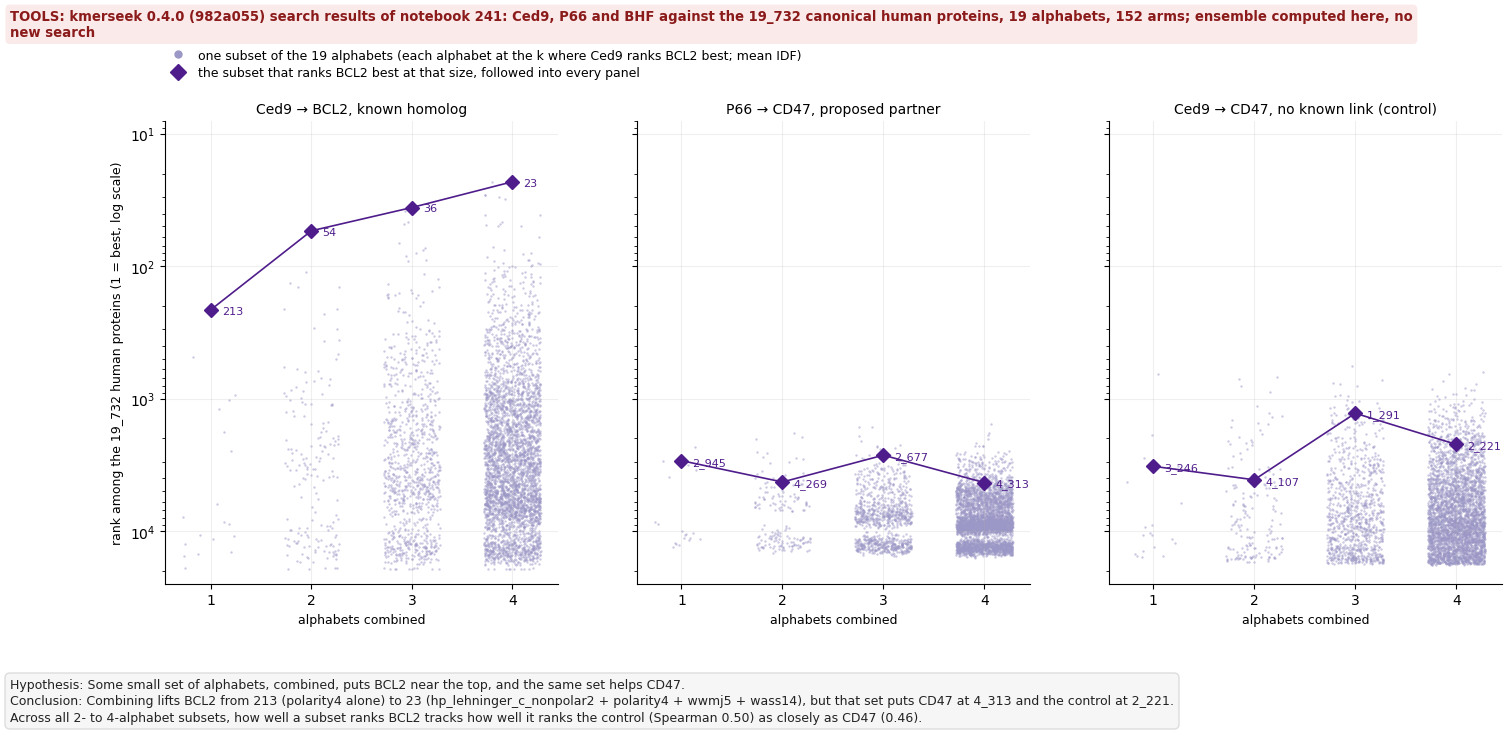

In [8]:
scan = ae.subset_scan("mean IDF", "best")
scan.write_parquet(ae.DATA / "subset_scan.best_k.mean_idf.parquet")
best_by_size = scan.sort("Ced9->BCL2").group_by("size").first().sort("size")
from scipy.stats import spearmanr as _sp
multi = scan.filter(pl.col("size") > 1)
rho_cd47 = _sp(multi["Ced9->BCL2"], multi["P66->CD47"]).statistic
rho_ctl = _sp(multi["Ced9->BCL2"], multi["Ced9->CD47"]).statistic
top50 = multi.sort("Ced9->BCL2").head(50)
membership = sorted(((sum(a in x.split(" + ") for x in top50["subset"]), a) for a in ae.ALPHABETS19), reverse=True)
b4 = best_by_size.filter(pl.col("size") == 4).row(0, named=True)
b1 = best_by_size.filter(pl.col("size") == 1).row(0, named=True)
ae.fig_subset_scan(
    scan, FIG / "242_every_subset_of_alphabets.png",
    hypothesis="Some small set of alphabets, combined, puts BCL2 near the top, and the same set helps CD47.",
    conclusion=(f"Combining lifts BCL2 from {b1['Ced9->BCL2']} ({b1['subset']} alone) to {b4['Ced9->BCL2']} "
                f"({b4['subset']}), but that set puts CD47 at {b4['P66->CD47']:_} and the control at {b4['Ced9->CD47']:_}. "
                f"Across all 2- to 4-alphabet subsets, how well a subset ranks BCL2 tracks how well it ranks the control "
                f"(Spearman {rho_ctl:.2f}) as closely as CD47 ({rho_cd47:.2f})."),
)
print(best_by_size.select("size", "subset", "Ced9->BCL2", "P66->CD47", "Ced9->CD47"))
print("\nbest subset for CD47 at each size:")
print(scan.sort("P66->CD47").group_by("size").first().sort("size").select("size", "subset", "Ced9->BCL2", "P66->CD47", "Ced9->CD47"))
print("\nhow often each alphabet appears in the 50 best subsets for BCL2:", [(a, n) for n, a in membership if n])
print("\nmedian rank over all subsets of each size:")
print(scan.group_by("size").agg(pl.col("Ced9->BCL2").median(), pl.col("P66->CD47").median(), pl.col("Ced9->CD47").median()).sort("size"))

## 7. The query-side null: does Ced9 rank BCL2 higher than a random query does?

Sections 1 to 4 compare the partner with the other human proteins for one query. The
direct test swaps the query: 300 random human proteins of the query's length (within 25%,
Bcl-2 family members and CD47 excluded) are searched on 19 arms, one per alphabet at its
lowest seed information, and each one's rank for BCL2 or CD47 is measured the same way.
The p-value is the share of random queries that rank the partner at least as high as the
true query does. If combining alphabets helps, the combined rank's p-value is smaller
than the best single arm's.

The search is run by `242_null_queries.py` (about 1.6 billion regions, about 3 hours with
3 workers); until its output exists this section says so and stops.

In [9]:
if not ae.null_available("lowest"):
    done, expected = ae.null_progress("lowest")
    print(f"The null run on each alphabet's lowest-bit arm is not complete ({done} of {expected or 494} chunks). "
          "Run or finish notebooks/242_null_queries.py --arms lowest, then re-execute this notebook.")
else:
    nul = ae.fig_null(
        FIG / "242_query_side_null.png",
        hypothesis="The true query ranks its partner higher than random queries of its length do, and combining alphabets widens the gap.",
        conclusion=(lambda t: (
            "; ".join(f"{r['case']} → {r['partner']}, {r['metric']}: best single arm p = {r['best_single_rank_p']:.3f}, "
                      f"combined p = {r['ensemble_rank_p']:.3f}" for r in t.filter(pl.col("metric").is_in(["mean IDF", "E-value"])).iter_rows(named=True))
            + "."))(pl.concat([ae.null_summary("Ced9", "BCL2"), ae.null_summary("P66", "CD47")])),
    )
    print(nul)

The null run on each alphabet's lowest-bit arm is not complete (107 of 446 chunks). Run or finish notebooks/242_null_queries.py --arms lowest, then re-execute this notebook.


### 7b. The best subset, against random queries given the same picks

Section 6 picked each alphabet's k and then the subset by how well they rank BCL2. Here
every random query gets the same two picks: the best subset of each size by its own rank
of the partner, with k either fixed at the k picked for Ced9 or each query's own best k.
The second rule is the fair one: Ced9's k was picked on its own answer too. This needs
the null run over all 152 arms (`242_null_queries.py --arms all`).

In [10]:
if not ae.null_available("all"):
    done, expected = ae.null_progress("all")
    print(f"The null run over all arms is not complete ({done} of {expected} chunks). "
          "Run notebooks/242_null_queries.py --arms all, then re-execute this notebook.")
else:
    for case, partner in [("Ced9", "BCL2"), ("P66", "CD47")]:
        tbl, dists = ae.null_subset_test(case, partner)
        fair = tbl.filter(pl.col("k_rule") == "each query's own best k")
        ae.fig_subset_null(
            dists, case, partner, FIG / f"242_best_subset_vs_random_queries.{partner}.png",
            hypothesis=f"{case}'s best subset of alphabets ranks {partner} higher than the best subset of a random query does.",
            conclusion=("With each query picking its own k and subset: " + "; ".join(
                f"{r['size']} alphabet{'s' if r['size'] > 1 else ''}, p = {r['p']:.3f}" for r in fair.iter_rows(named=True)) + "."),
        )
        print(tbl)

The null run over all arms is not complete (107 of 1096 chunks). Run notebooks/242_null_queries.py --arms all, then re-execute this notebook.


## 8. Conclusions

**Combining alphabets does not lift either partner.** Under every one of the five metrics
the combined rank of BCL2 and CD47 is worse than their best single arm: BCL2 falls from
213 to about 7_000 to 13_000, CD47 from 166 to about 7_000 to 9_000.

**Because the crowd is the same.** Under mean IDF about 1_200 proteins beat BCL2 in at least
half of the 13 alphabets that see it, 8 times what independent alphabets would give; for
CD47 about 3_900, 3.7 times. The alphabets are functions of the same two sequences, and
the proteins that beat the partner in one mostly beat it in the others.

**What a rank product rewards is length.** Across the three queries and two metrics tested
the combined rank correlates with protein length at Spearman 0.71 to 0.84, and the top of
BHF's combined list is TTN, MUC16, OBSCN and other giant proteins. A combination that
treats "not hit here" as a bottom rank favours proteins that are hit everywhere.

**CD47 is a sticky target.** Ced9, with no known link to CD47, ranks it 21st at its best
single arm and 744th combined (Poisson p-value), above where P66 puts it and above where
Ced9 puts BCL2. CD47 has 33 membrane-helix-like hydrophobic windows, BCL2 none. A high rank
of CD47 for P66 is weak evidence for a P66-CD47 link. Section 5 measures how often random
queries of P66's length rank CD47 as high.

**Three alphabets instead of 19 does not change that.** Combining only hp_lehninger2,
polarity4 and funcgroups8 (section 5) puts BCL2 at 3_561 and CD47 at 3_916 at best, better
than all 19 combined and worse than polarity4 alone for BCL2 (213). It lifts Ced9's rank
of CD47, the control with no known link, to 12. Nine proteins beat BCL2 in all three
alphabets, so no rule that requires agreement can rank it above 10.

**Choosing the alphabets and their k for BCL2 does lift it, on the answer it was chosen on.**
With each alphabet at the k where Ced9 ranks BCL2 best and scored by mean IDF (section 6),
the best subsets put BCL2 at 54 (polarity4 + wass14), 36 (three alphabets) and 23 (four:
hp_lehninger_c_nonpolar2, polarity4, wwmj5, wass14), against 213 for polarity4 alone. The
same four put CD47 at 4_313 and the control at 2_221. Over all 2- to 4-alphabet subsets,
how well a subset ranks BCL2 tracks how well it ranks the control (Spearman 0.50) as
closely as CD47 (0.46). Whether rank 23 is more than the best of 5_016 tries is what
section 7b measures, by giving 300 random queries the same two choices.

**What could still work.** A combination that does not reward being hit: rank only among
the proteins every alphabet hits, or normalise each protein's score by how often it is hit
by random queries (the section 5 run gives that background for BCL2 and CD47). Neither
changes the bits the pair carries, so the E-value stays far above 1.